# Notebook 04: Redes Convolucionales (Conv1D)
En este notebook entrenaremos los modelos y evaluaremos su rendimiento.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt

from src.data import cargar_returns
from src.models import build_conv1d_model
from src.training import entrenar_todos_los_modelos
from src.evaluation import construir_matriz_resultados


## Cargar datos

In [2]:
returns = cargar_returns(verbose=True)

[cargar_returns] Cargados 16195 días, 23 activos


## Definir y entrenar arquitecturas
Aquí definimos las funciones lambda para crear los modelos usando la base del `src/models.py`.

In [3]:
builders = {
    "Conv1D_Small": lambda s: build_conv1d_model(s, filters=[32], kernel_size=3),
    "Conv1D_Medium": lambda s: build_conv1d_model(s, filters=[64, 32], kernel_size=5),
    "Conv1D_Large": lambda s: build_conv1d_model(s, filters=[128, 64, 32], kernel_size=3, dropout=0.2)
}

# Entrenar (puede tardar bastante)
resultados = entrenar_todos_los_modelos(
    builders=builders,
    returns=returns,
    epochs=100,
    batch_size=32,
    patience=10,
    verbose=0
)

[1/48] Entrenando Conv1D_Small_V5_H1...


Epoch 21: early stopping


Restoring model weights from the end of the best epoch: 11.


    MAE test=0.01231  params=4471  épocas=21
[2/48] Entrenando Conv1D_Medium_V5_H1...


Epoch 11: early stopping


...

Restoring model weights from the end of the best epoch: 5.


    MAE test=0.00129  params=34647  épocas=15
[48/48] Entrenando Conv1D_Large_V90_H90...


Epoch 23: early stopping


Restoring model weights from the end of the best epoch: 13.


    MAE test=0.00128  params=48631  épocas=23


## Guardar resultados

In [4]:
df = pd.DataFrame(resultados).round(6)
tables_dir = project_root / "results" / "tables"
df.to_csv(tables_dir / '04_competicion_cnn.csv', index=False)
df.head()

,modelo,V,H,MAE_train,MAE_val,MAE_test,n_params,epocas_entrenadas
0,Conv1D_Small,5,1,0.011580,0.009204,0.012306,4471,21
1,Conv1D_Medium,5,1,0.011723,0.009206,0.012280,19191,11
2,Conv1D_Large,5,1,0.011689,0.009208,0.012272,40535,21
3,Conv1D_Small,5,5,0.005322,0.004298,0.005671,4471,22
4,Conv1D_Medium,5,5,0.005375,0.004304,0.005610,19191,17


## Visualización (Heatmaps)

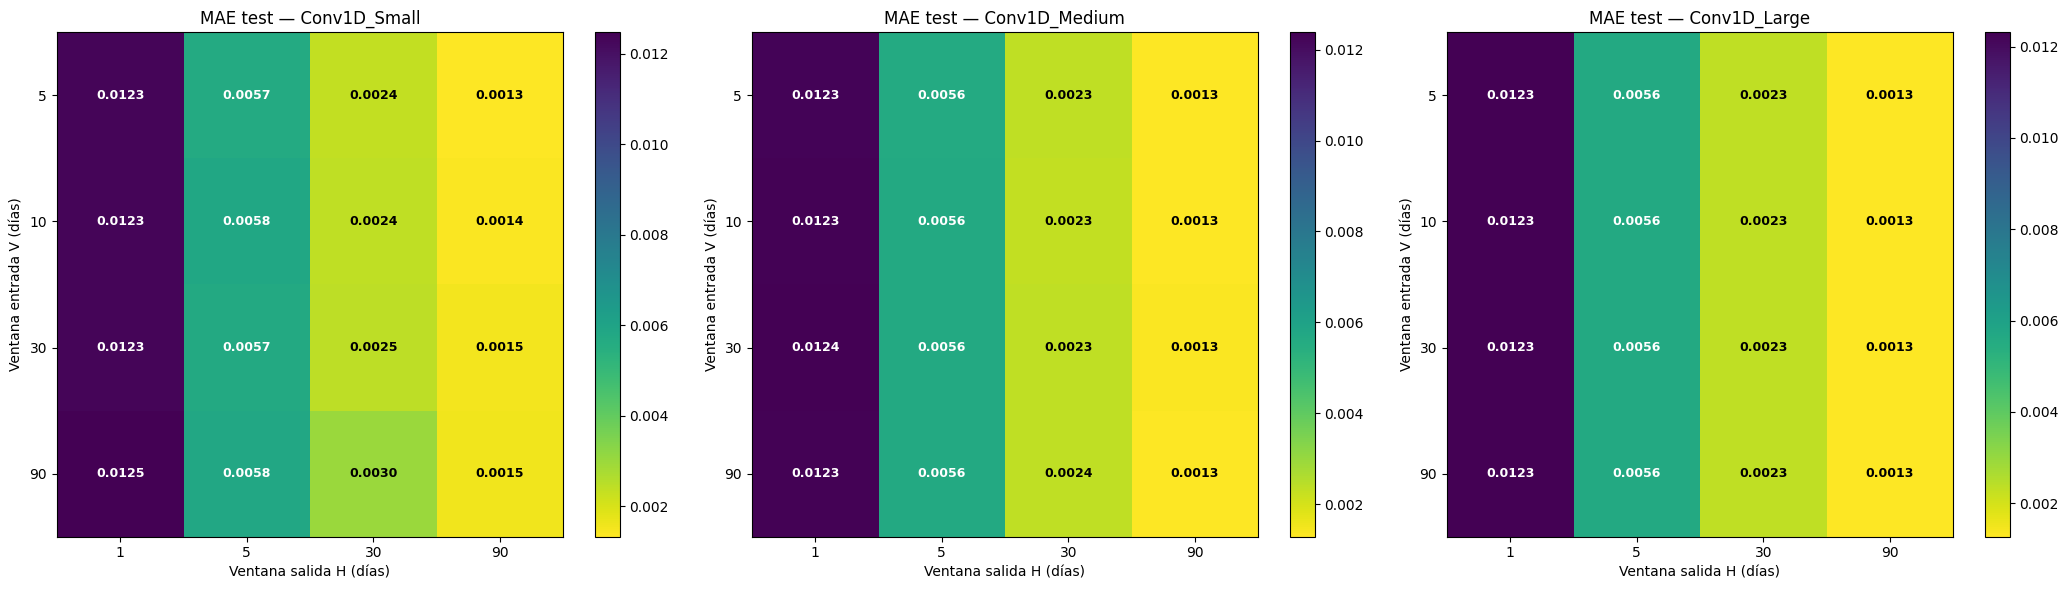

In [5]:
import numpy as np

modelos = list(builders.keys())
INPUT_WINDOWS  = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]

fig, axes = plt.subplots(1, len(modelos), figsize=(7*len(modelos), 6))
if len(modelos) == 1: axes = [axes]

for idx, modelo in enumerate(modelos):
    df_modelo = df[df["modelo"] == modelo]
    resultados_modelo = df_modelo.to_dict("records")
    matriz = construir_matriz_resultados(resultados_modelo, INPUT_WINDOWS, OUTPUT_WINDOWS)

    ax = axes[idx]
    im = ax.imshow(matriz, cmap="viridis_r", origin="upper", aspect="auto")

    # Anotar valores
    for i in range(len(INPUT_WINDOWS)):
        for j in range(len(OUTPUT_WINDOWS)):
            val = matriz[i, j]
            if not np.isnan(val):
                color = "white" if val > np.nanmedian(matriz) else "black"
                ax.text(j, i, f"{val:.4f}", ha="center", va="center", color=color, fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(OUTPUT_WINDOWS)))
    ax.set_yticks(range(len(INPUT_WINDOWS)))
    ax.set_xticklabels(OUTPUT_WINDOWS)
    ax.set_yticklabels(INPUT_WINDOWS)
    ax.set_xlabel("Ventana salida H (días)")
    ax.set_ylabel("Ventana entrada V (días)")
    ax.set_title(f"MAE test — {modelo}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
figures_dir = project_root / "results" / "figures"
plt.savefig(figures_dir / '04_competicion_cnn_matrices.png', bbox_inches="tight", dpi=120)
plt.show()